# Kerr oscillator model

This model describes a single photonic mode subject to photon-photon interaction U, two-photon drive F , and losses $\gamma$. We work here in the frequency frame of the drive,
such that $\Delta = \omega_0 − \omega_d$ , where $\omega_0$ is the mode bare frequency and $\omega_d$ is the drive frequency. It is well known to display bistability , i.e., the coexistence of two stablesteady-state solutions at mean-field level, which seemed tocontradict the necessary uniqueness of the quantum ground state. [1]


When two photon driving is used, the system has a parity symmetry; it has been shown theoretically that this symmetry can be spontaneously broken in the steady state, leading to a continuous phase transition. Recently, this symmetry breaking has found applications in quantum error correction . Furthermore, phase transitions in either a few or a lattice of coupled Kerr oscillators have also been explored. Dissipative phase transitions have also been studied in a dissipative cavity with other types of nonlinearity, such as coupling with atoms. [2]

Previous approaches to the phase transition in a Kerr oscillator are usually limited to finite system size. Here, using the Keldysh formalism, we access the thermodynamic limit directly. [2]

[1] : Analytical phase boundary of a quantum driven-dissipative Kerr oscillator from classical stochastic instantons https://journals.aps.org/prresearch/pdf/10.1103/528d-l76d 

[2] : Driven-dissipative phase transition in a Kerr oscillator: From semiclassical PT symmetry to quantum fluctuations doi: 
10.1103/PhysRevA.103.033711

$$
\hat H  = -\Delta \hat a^\dagger \hat a + \frac{K}{2}\hat a^{\dagger2} \hat a^2 -  \frac{\varepsilon}{4}(\hat a^{\dagger2} + \hat a^2)
$$
## Ecuacion de Lindblad

$$
\frac{d\hat\rho}{dt} = -i[\hat H ,\hat \rho] + \gamma_1 \mathbb{D}[\hat a^\dagger] + \gamma_1 \mathbb{D}[\hat a] + \gamma_1 \mathbb{D}[\hat a^{2\dagger}] + \gamma_1 \mathbb{D}[\hat a^2]
$$
Donde $\mathbb D[\hat L]$ es el disipador con operador de salto L.
$$
\mathbb D[\hat L] = \hat L^\dagger \hat \rho \hat L - \frac{1}{2} \{\hat L^\dagger \hat L, \hat \rho\}
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.integrate import odeint



In [18]:

def Kerr_system(N, Delta, K, Epsilon):
    a = destroy(N) 
    """
Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa 
        Lindbladiano: del sistema para un oscilador de Kerr 
        Expect_ops: np.array[] de los operadores que se requiera su valor esperado

     Hamiltoniano Kerr Oscillator de acuerdo al paper de Zhang2021:
         Detuning         (omega_d)
         No linealidad de Keer  (U)
         Squeezing              (G)
    """

    H = (
        - Delta*a.dag()*a               
        +  0.5*K* a.dag()*a.dag() *a*a       
        + 0.25*Epsilon* (a.dag()*a.dag() + a*a) 
        )
    
    return H
    
def Kerr_Diag(N, Delta, K, Epsilon, Jump_ops):
 
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    Regresa
        Eigenvalores del sistema.
    '''
    
    H = Kerr_system(N, Delta, K, Epsilon)
    L = liouvillian(H, Jump_ops)
    eigs = L.eigenenergies()

    return eigs

def Kerr_evo(N, Delta, K, Epsilon, Jump_ops, Expected_ops):
    '''
    Esta función toma:
        Escalares
            N: Dim Hilbert
            Delta: Detuning
            K: Kerr NL
            Epsilon: Squeezing
        Jump_ops: np.array[] de los operadores de salto
        
    
    Regresa 
        Estados evolucionados para cada paso de tiempo
        Evolución del valor de expectacion de los Expect_ops
    '''
    t = linspace(0,10, 100) # 100 pasos de tiempo entre 0 - 10
    H = Kerr_system(N, Delta, K, Epsilon)

    init_rho = coherent(N, 1)
    evo = mesolve(H, init_rho, t, Jump_ops, Expect_ops)

    return evo 

    



In [77]:
# -----------------------Parametros-------------------------------
N = 100              # dim Hilbert space
# Loss 
g = 1        
K_list = np.array(
    [1/15, 1/30, 1/60, 1/75, 1/90]     # Interaction, Kerr NL
    )             
Delta = 0                         # Detuning 
epsi_list = np.linspace(0.01,2,200)    # Squeezing

a = destroy(N)
n = a.dag() * a
# Operadores de salto
Loss_1photo = [ np.sqrt(g)*a ]
Loss_2photo = [ np.sqrt(g)*a*a ]


"""
Calcular valor esperado de N para diferentes epsilon, en el ss
"""
# Para perdida de un fotón
n_1values = []

for K in K_list:

    n_values = []

    for e in epsi_list:

        H = Kerr_system(N, Delta, K, e)
        rho_ss = steadystate(H, Loss_1photo)

        n_ss = expect(n, rho_ss)

        n_values.append(n_ss)

    n_1values.append(np.array(n_values))  
print(n_1values)
print('-----------------------------------Finished------------------------------------')


KeyboardInterrupt: 

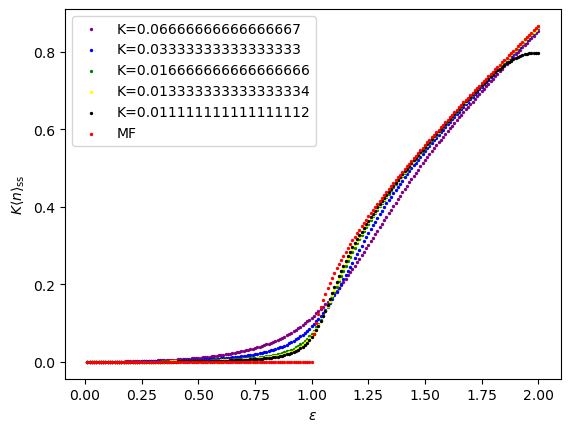

In [8]:
#---------- Mean Field -------------

r = np.clip(epsi_list**2 - g**2, a_min=0, a_max=None)
n_mf = 0.5 * np.sqrt(r)
"""
Para la grafica en el eje x seria mi epsi_list y el eje y es K*n_1values
"""
colors = ['purple', 'blue', 'green', 'yellow', 'black', 'pink']

for i, K in enumerate(K_list):
    plt.scatter(epsi_list , K*n_1values[i], c = colors[i], s = 2, label=f"K={K}" )

plt.scatter(epsi_list, n_mf, c = 'red', s= 2, label = 'MF')
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$K\langle n\rangle_{\rm ss}$")
plt.legend()


plt.savefig('n_vs_epsilon_1photon.pdf')
plt.show()

In [ ]:
''''
Prueba con diferentes espacios de Hilbert, hay una falla numerica cuando N=100
'''

# -----------------------Parametros-------------------------------
N = [20,40,60,80,100]           # dim Hilbert space
# Loss 
g = 1        
K_list = np.array(
    [1/20]     # Interaction, Kerr NL
    )           
Delta = 0                         # Detuning 
epsi_list = np.linspace(0.01,2,10)    # Squeezing


# Operadores de salto
#Loss_2photo = [ np.sqrt(g)*(a*a) ]


"""
Calcular valor esperado de N para diferentes epsilon, en el ss
"""
# Para perdida de 2 fotones
n_2values = []

print(
    f'Delta = {Delta},'
    f'gamma = {g}'
    '\n'
    )

for d in N:
    a = destroy(d)
    n = a.dag() * a
    print(f"N = {d}")    
    for K in K_list:
    
        n_values = []
    
        for e in epsi_list:
    
            H = Kerr_system(d, Delta, K, e)
            rho_ss = steadystate(
                H, 
                np.sqrt(g)*(a*a),
                method='direct'
                )
            print(
            f"K={K:.6f}, "
            rf"eps={e:.4f},"
            f"<n>={expect(n,rho_ss):.8f}, "
            f"Tr={rho_ss.tr():.8f}, "
            f"Tr^2={(rho_ss*rho_ss).tr():.8f}, "
            f"minEig={np.min(rho_ss.eigenenergies()):.3e}"
        )
            n_ss = expect(n, rho_ss)
    
            n_values.append(n_ss)
    print('\n')
        n_2values.append(np.array(n_values))  
# print(n_2values)
print('-----------------------------------Finished------------------------------------')



In [64]:
# -----------------------Parametros-------------------------------
N = [20]           # dim Hilbert space
# Loss 
g = 1        
K_list = np.array(
    [1/15, 1/30, 1/60, 1/75, 1/90]     # Interaction, Kerr NL
    )           
Delta = 0                         # Detuning 
epsi_list = np.linspace(0.01,2,100)    # Squeezing


# Operadores de salto
#Loss_2photo = [ np.sqrt(g)*(a*a) ]


"""
Calcular valor esperado de N para diferentes epsilon, en el ss
"""
# Para perdida de 2 fotones
n_2values = []

print(
    f'Delta = {Delta},'
    f'gamma = {g}'
    '\n'
)
for d in N:
    a = destroy(d)
    n = a.dag() * a
    print(f"N = {d}")    
    for K in K_list:
    
        n_values = []
    
        for e in epsi_list:
    
            H = Kerr_system(d, Delta, K, e)
            rho_ss = steadystate(
                H, 
                np.sqrt(g)*(a*a),
                method='direct'
                )
            print(
            f"K={K:.6f}, "
            rf"eps={e:.4f},"
            f"<n>={expect(n,rho_ss):.8f}, "
            f"Tr={rho_ss.tr():.8f}, "
            f"Tr^2={(rho_ss*rho_ss).tr():.8f}, "
            f"minEig={np.min(rho_ss.eigenenergies()):.3e}"
        )
            n_ss = expect(n, rho_ss)
            n_values.append(n_ss)
        print('\n')
            
    print('\n')
    n_2values.append(np.array(n_values))  
# print(n_2values)
print('-----------------------------------Finished------------------------------------')



Delta = 0,gamma = 1

N = 20
K=0.066667, eps=0.0100,<n>=0.00002489, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.163e-16
K=0.066667, eps=0.0301,<n>=0.00022550, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.498e-17
K=0.066667, eps=0.0502,<n>=0.00062714, Tr=1.00000000, Tr^2=1.00000000, minEig=-3.540e-19
K=0.066667, eps=0.0703,<n>=0.00122966, Tr=1.00000000, Tr^2=1.00000000, minEig=-1.167e-18
K=0.066667, eps=0.0904,<n>=0.00203280, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.174e-19
K=0.066667, eps=0.1105,<n>=0.00303626, Tr=1.00000000, Tr^2=1.00000000, minEig=-3.183e-16
K=0.066667, eps=0.1306,<n>=0.00423962, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.543e-17
K=0.066667, eps=0.1507,<n>=0.00564240, Tr=1.00000000, Tr^2=1.00000000, minEig=-2.045e-17
K=0.066667, eps=0.1708,<n>=0.00724405, Tr=1.00000000, Tr^2=1.00000000, minEig=-6.989e-20
K=0.066667, eps=0.1909,<n>=0.00904392, Tr=1.00000000, Tr^2=1.00000000, minEig=-1.425e-17
K=0.066667, eps=0.2110,<n>=0.01104131, Tr=1.00000000, Tr^2=1.00000000, minEig=-1.1

In [76]:

print(len(n_2values))

1


5


IndexError: list index out of range

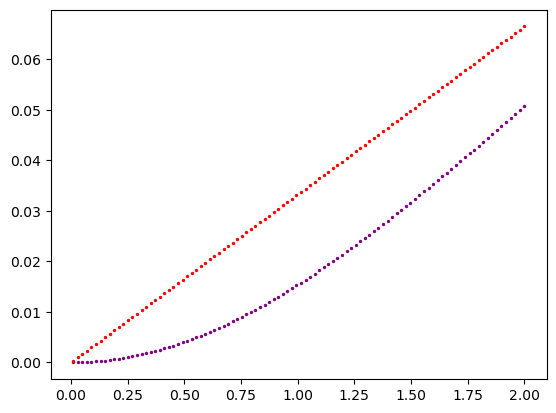

In [73]:
#---------- Mean Field -------------
n_mf = []
for k in K_list:
    mf = []
    for e in epsi_list:
        
        r = e**2/(k**2 + g**2)
        n_mfx = 0.5 * np.sqrt(r)
        mf.append(n_mfx) 
    n_mf.append(np.array(mf))  
print(len(n_mf))
    
"""
Para la grafica en el eje x seria mi epsi_list y el eje y es K*n_2values
"""
colors = ['purple', 'blue', 'green', 'yellow', 'black']

for i, K in enumerate(K_list):
    plt.scatter(epsi_list , K*n_2values[i], c = colors[i], s = 2, label=f"K={K}" )
    plt.scatter(epsi_list, K*n_mf[i], c = 'red', s= 2)
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\langle n\rangle_{\rm ss}$")
plt.legend()
plt.savefig('n_vs_epsilon_2ph1.pdf')
plt.grid(0.5)
plt.show()


In [9]:
print(len(n_1values[0]))
print(range(len(K_list)))

y = 1/1000*epsi_list 
#plt.plot(epsi_list, y)
#plt.ylim(0,0.1)

200
range(0, 5)


In [12]:
N=50
a= destroy(N)
Delta = 0
g = 1.0      # Tasa de disipación
k = 1.0          # No linealidad de Kerr (U)
epsilon = 1.5   # Amplitud de driving paramétrico (G)
L_op = [ np.sqrt(g)*a ]
eigs = Kerr_Diag(N, Delta, k, epsilon, L_op)

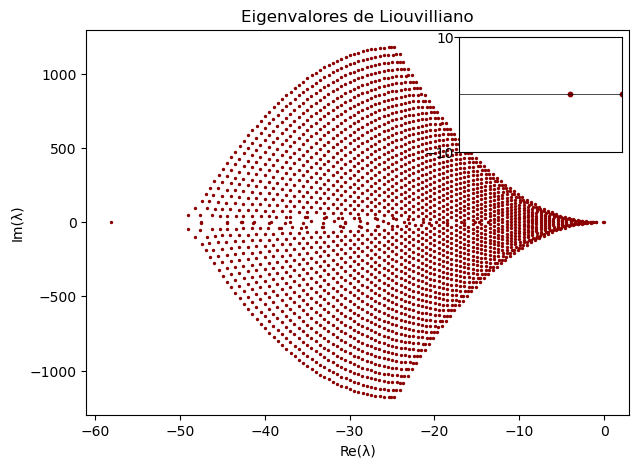

In [15]:


X = np.real(eigs)
Y = np.imag(eigs)

fig, ax = plt.subplots(figsize=(7,5))

# Grafica principal
ax.scatter(X, Y, s=2, c='darkred')
ax.set_xlabel("Re(λ)")
ax.set_ylabel("Im(λ)")
ax.set_title("Eigenvalores de Liouvilliano")
# -------------------------
# Zoom
# -------------------------
axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

axins.scatter(X, Y, s=10, c='darkred')

# Limites de la region a ampliar
x1, x2 = -0.5, 0
y1, y2 = -10, 10

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.axhline(0, c='black', lw=0.5)

# Opcional: quitar labels pequeños
axins.tick_params(axis='y',
                  direction='out',
                  labelsize=10,
                  pad=0)
axins.set_xticks([])
axins.set_yticks([y1,y2])

plt.savefig('eigsKerr_1ph.pdf')
plt.show()


# Espacio fase para un solo canal fotonico
Haciendo el MF obtenemos
$$
\frac{d\alpha}{dt} = (i\Delta - iKn - \frac{\gamma}{2})\alpha - i \frac{\varepsilon}{2} \alpha^*
$$
Donde n = $|\alpha|^2$. La solución para el steady state $d\alpha / dt = 0$
$$
K n = \Delta \mp \frac{1}{2} \sqrt{\varepsilon^2 - \gamma^2}
$$
En el paper de Zhang2021 se centran cuando no hay detuning $\Delta = 0$ Entonces podemos obtener la fase de $\alpha$
$$
e^{i2\theta} =  -\frac{1}{\varepsilon^*} \left(\sqrt{\varepsilon^2 - \gamma^2} +  i\gamma \right)
$$
Podemos observar el espacio fase, conociendo como evoluciona $\alpha$ y  $\alpha^*$

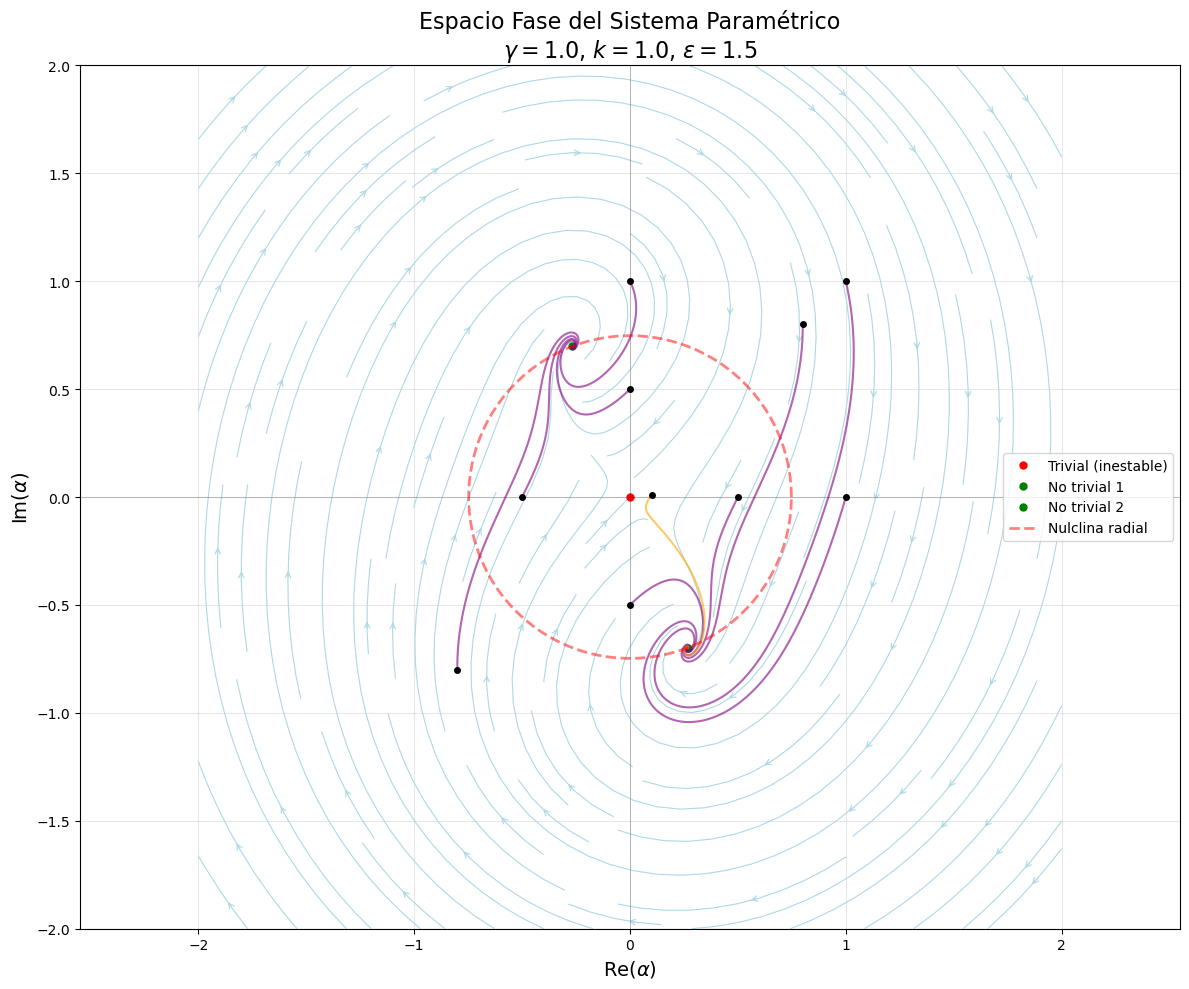

PUNTOS FIJOS DEL SISTEMA
Trivial (inestable):
  α = 0.0000+0.0000j
  |α| = 0.0000
  θ = 0.0000 rad

No trivial 1:
  α = 0.2668-0.6985j
  |α| = 0.7477
  θ = -1.2059 rad

No trivial 2:
  α = -0.2668+0.6985j
  |α| = 0.7477
  θ = 1.9357 rad


ESTABILIDAD APROXIMADA:
  • Punto trivial (α=0): Inestable (silla)
  • Puntos no triviales: Estables (atractores)


In [15]:

# ============================================
# PARAMETROS DEL SISTEMA 
# (En el paper no usan Detuning, \Delta = 0 = \omega_d)
# ============================================
gamma = 1.0      # Tasa de disipación
k = 1.0          # No linealidad de Kerr (U)
epsilon = 1.5   # Amplitud de driving paramétrico (G)

# ============================================
# SISTEMA DE ECUACIONES
# ============================================
def sistema(y, t, gamma, k, epsilon):

    alpha = y[0] + 1j*y[1]
    
    dalpha_dt = (-1j * k * np.abs(alpha)**2 - gamma/2) * alpha - 1j * epsilon/2 * np.conj(alpha)
    
    return [np.real(dalpha_dt), np.imag(dalpha_dt)]

# ============================================
# PUNTOS FIJOS (ESTADO ESTACIONARIO)
# ============================================
def puntos_fijos(gamma, k, epsilon):
    """
    Calcula los puntos fijos del sistema.
    """
    puntos = []
    
    # Punto fijo trivial n = 0
    puntos.append((0, 0, 'Trivial (inestable)'))
    
    # Puntos fijos no triviales (eps > gamma)
    if epsilon > gamma:
        r2 = np.sqrt(epsilon**2 - gamma**2) / (2 * k)
        r = np.sqrt(r2)
        
        # La fase se determina por la ecuación de fase
        # e^{2iθ} = -(sqrt(epsilon^2 - gamma^2) + i*gamma)/epsilon
        # (eps > 0 )
        numerador = -(np.sqrt(epsilon**2 - gamma**2) + 1j*gamma)
        fase = numerador / epsilon
        
        # Extraer fase
        theta = 0.5 * np.angle(fase)
        
        # Dos soluciones con fase θ y θ + π (simetría Z2)
        alpha1 = r * np.exp(1j * theta)
        alpha2 = r * np.exp(1j * (theta + np.pi))
        
        puntos.append((np.real(alpha1), np.imag(alpha1), 'No trivial 1'))
        puntos.append((np.real(alpha2), np.imag(alpha2), 'No trivial 2'))
    
    return puntos

# ============================================
# FUNCIÓN PARA GENERAR EL CAMPO VECTORIAL
# ============================================
def campo_vectorial(X, Y, gamma, k, epsilon):
    """
    Calcula el campo vectorial en el plano (X, Y).
    """
    U = np.zeros_like(X)
    V = np.zeros_like(Y)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            alpha = X[i,j] + 1j*Y[i,j]
            dalpha_dt = (-1j * k * np.abs(alpha)**2 - gamma/2) * alpha - 1j * epsilon/2 * np.conj(alpha)
            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)
    
    return U, V

# ============================================
# FUNCIÓN PARA TRAZAR TRAYECTORIAS
# ============================================
def trayectoria(alpha0, t_max=20, n_points=1000):
    """
    Calcula la trayectoria desde una condición inicial alpha0.
    """
    t = np.linspace(0, t_max, n_points)
    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)
    sol = odeint(sistema, [X_0,Y_0], t, args=(gamma, k, epsilon))
    return sol[:, 0] + 1j*sol[:, 1], t

# ============================================
# NULCLINAS
# ============================================
# Las nulclinas son curvas donde dα/dt = 0
# Para este sistema, la nulclina satisface:
# (-ik|α|^2 - γ/2)α - iε/2 α* = 0

def nulclina_real(gamma, k, epsilon):
    """Calcula la nulclina para la parte real."""
    # La ecuación es compleja, resolvemos numéricamente
    # dα/dt = 0 => α = 0 o |α|^2 = sqrt(ε^2 - γ^2)/(2k)
    if epsilon > gamma:
        r = np.sqrt(np.sqrt(epsilon**2 - gamma**2) / (2*k))
        # La nulclina es un círculo de radio r (para la parte radial)
        # Más precisamente, es la curva donde la parte radial es cero
        theta = np.linspace(0, 2*np.pi, 100)
        x_circ = r * np.cos(theta)
        y_circ = r * np.sin(theta)
        return x_circ, y_circ
    else:
        return np.array([]), np.array([])


# ============================================
# CONFIGURACIÓN DE LA GRÁFICA
# ============================================
plt.figure(figsize=(12, 10))

# Rango del espacio fase
lim = 2.0
x = np.linspace(-lim, lim, 30)
y = np.linspace(-lim, lim, 30)
X, Y = np.meshgrid(x, y)

# Calcular campo vectorial
U, V = campo_vectorial(X, Y, gamma, k, epsilon)

# Graficar campo vectorial (flujo)
plt.streamplot(X, Y, U, V, color='lightblue', linewidth=0.8, density=1.2, 
               arrowstyle='->', arrowsize=1.0)

# Calcular y graficar puntos fijos
puntos = puntos_fijos(gamma, k, epsilon)
for xp, yp, label in puntos:
    if 'Trivial' in label:
        plt.plot(xp, yp, 'ro', markersize=5, label=label)
    else:
        plt.plot(xp, yp, 'go', markersize=5, label=label)

# Graficar algunas trayectorias representativas
ini_con = [
    0.5 + 0.0j,
    0.0 + 0.5j,
    -0.5 + 0.0j,
    0.0 - 0.5j,
    0.8 + 0.8j,
    -0.8 - 0.8j,
    1.0 + 0.0j,
    0.0 + 1.0j,
    1.0 + 1.0j,
    0.1 + 0.01j
]

for alpha0 in ini_con:
    tray, t = trayectoria(alpha0, t_max=30, n_points=2000)
    
    # Color según la condición inicial
    if np.abs(alpha0) < 0.3:
        color = 'orange'
    else:
        color = 'purple'
    
    plt.plot(np.real(tray), np.imag(tray), color=color, alpha=0.6, linewidth=1.5)
    
    # Marcar punto inicial
    plt.plot(np.real(alpha0), np.imag(alpha0), 'k.', markersize=8)

plt.axhline(0, color='black', linewidth=0.5, alpha=0.3)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.3)
plt.xlabel('Re($\\alpha$)', fontsize=14)
plt.ylabel('Im($\\alpha$)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.title(f'Espacio Fase del Sistema Paramétrico\n'
          f'$\\gamma = {gamma}$, $k = {k}$, $\\epsilon = {epsilon}$', 
          fontsize=16)
plt.legend(loc='best')
plt.axis('equal')
#plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.tight_layout()

# Graficar nulclinas (círculo donde la dinámica radial se anula)
if epsilon > gamma:
    x_circ, y_circ = nulclina_real(gamma, k, epsilon)
    plt.plot(x_circ, y_circ, 'r--', linewidth=2, label='Nulclina radial', alpha =0.5)
    plt.xlabel('Re($\\alpha$)', fontsize=14)
    plt.ylabel('Im($\\alpha$)', fontsize=14)
    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig('PhaseSpace1ph.pdf')
    plt.show()
else:
    plt.show()
# ============================================
# INFORMACIÓN DE LOS PUNTOS FIJOS
# ============================================
print("="*50)
print("PUNTOS FIJOS DEL SISTEMA")
print("="*50)
for xp, yp, label in puntos:
    alpha = xp + 1j*yp
    r = np.abs(alpha)
    theta = np.angle(alpha)
    print(f"{label}:")
    print(f"  α = {alpha:.4f}")
    print(f"  |α| = {r:.4f}")
    print(f"  θ = {theta:.4f} rad")
    print()

# Verificar estabilidad (aproximada)
print("\nESTABILIDAD APROXIMADA:")
print("  • Punto trivial (α=0):", "Inestable (silla)" if epsilon > gamma else "Estable")
print("  • Puntos no triviales:", "Estables (atractores)" if epsilon > gamma else "No existen")




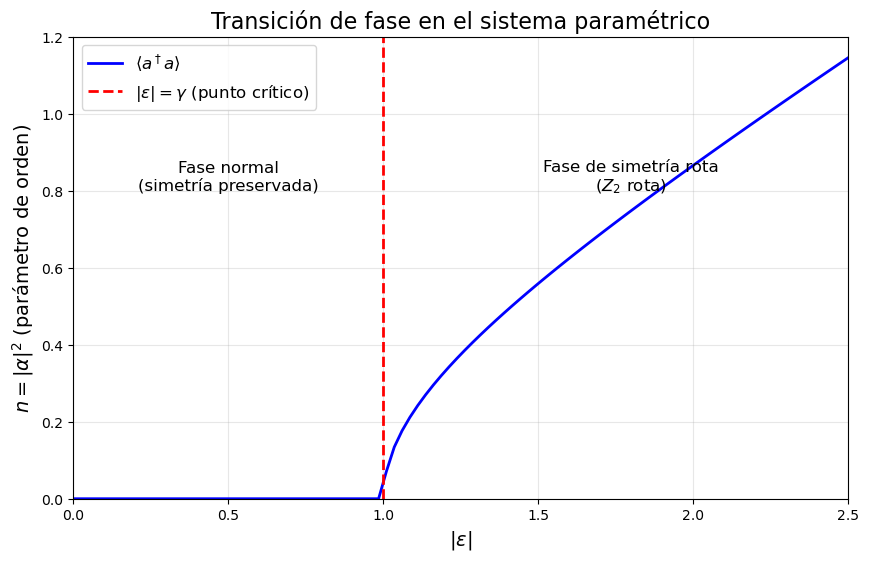

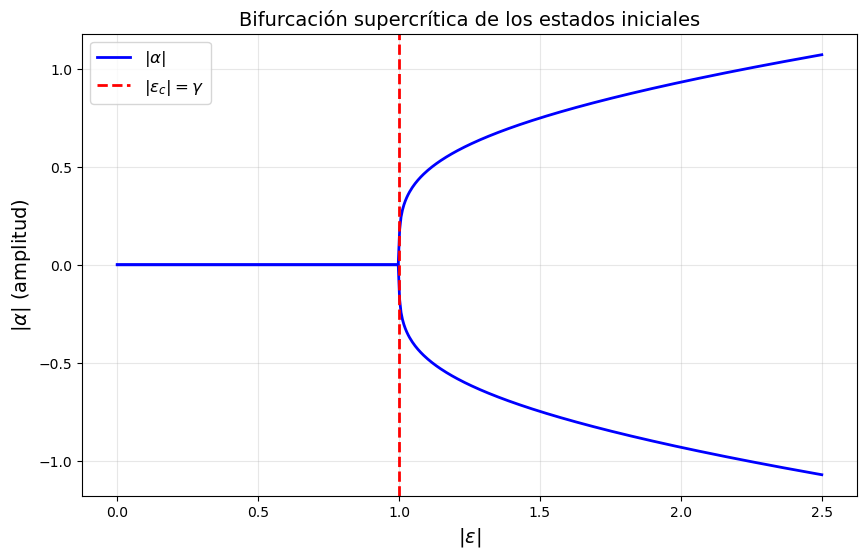

ANÁLISIS DE TRANSICIONES DE FASE

1. TRANSICIÓN PRINCIPAL:
   • Punto crítico: |ε_c| = γ = 1.0
   • Para |ε| < 1.0: Fase normal (α = 0 estable)
   • Para |ε| > 1.0: Fase de simetría rota (α ≠ 0)

2. EXPONENTES CRÍTICOS:
   • Exponente β = 0.531 (teórico: β = 1/2 para campo medio)
   • n ∝ (|ε| - γ)^β

3. PARÁMETRO DE ORDEN:
   • n = |α|² = √(|ε|² - γ²)/(2k)
   • Para |ε| = 2γ: n = 0.866

4. CONDICIONES PARA LA TRANSICIÓN:
   • |ε| > γ: Ruptura de simetría Z₂
   • |ε| = γ: Punto crítico (transición de segundo orden)
   • k > 0: Necesario para estabilidad de la fase rota

5. COMPORTAMIENTO ASINTÓTICO:
   • |ε| >> γ: n ≈ |ε|/(2k)
   • |ε| → γ⁺: n → 0 (transición continua)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import fsolve

# ============================================
# PARÁMETROS
# ============================================
gamma = 1.0
k = 1.0

# ============================================
# ANÁLISIS DE PUNTOS FIJOS EN FUNCIÓN DE EPSILON
# ============================================
def analizar_transiciones(gamma, k, eps_values):
    """
    Analiza los puntos fijos para diferentes valores de epsilon.
    """
    resultados = {
        'eps': [],
        'n_puntos': [],
        'alpha0': [],
        'estabilidad': []
    }
    
    for eps in eps_values:
        eps_abs = np.abs(eps)
        
        # Punto trivial
        alphas = [0+0j]
        estabilidad = ['estable' if eps_abs < gamma else 'inestable']
        
        # Puntos no triviales
        if eps_abs > gamma:
            r2 = np.sqrt(eps_abs**2 - gamma**2) / (2 * k)
            r = np.sqrt(r2)
            
            # Fase (asumiendo eps real para simplificar)
            if np.isreal(eps):
                theta = 0
            else:
                numerador = -(np.sqrt(eps_abs**2 - gamma**2) + 1j*gamma)
                e2iθ = numerador / np.conj(eps)
                theta = 0.5 * np.angle(e2iθ)
            
            alpha1 = r * np.exp(1j * theta)
            alpha2 = r * np.exp(1j * (theta + np.pi))
            
            alphas.extend([alpha1, alpha2])
            estabilidad.extend(['estable', 'estable'])
        
        resultados['eps'].append(eps)
        resultados['n_puntos'].append(len(alphas))
        resultados['alpha0'].append(alphas)
        resultados['estabilidad'].append(estabilidad)
    
    return resultados

# ============================================
# PARÁMETRO DE ORDEN
# ============================================
def parametro_orden(gamma, k, eps_values):
    """
    Calcula el parámetro de orden |α|² en función de epsilon.
    """
    n_values = []
    
    for eps in eps_values:
        eps_abs = np.abs(eps)
        if eps_abs > gamma:
            r2 = np.sqrt(eps_abs**2 - gamma**2) / (2 * k)
            n_values.append(r2)
        else:
            n_values.append(0)
    
    return np.array(n_values)

# ============================================
# ENERGÍA EFECTIVA (POTENCIAL)
# ============================================
def potencial_efectivo(r, gamma, k, epsilon):
    """
    Potencial efectivo del sistema (aproximación).
    V(r) = -γ r²/2 + k r⁴/2 - |ε| r²/2
    """
    eps_abs = np.abs(epsilon)
    return -gamma/2 * r**2 + k/2 * r**4 - eps_abs/2 * r**2

# ============================================
# GRÁFICA 1: PARÁMETRO DE ORDEN
# ============================================
eps_range = np.linspace(0, 2.5, 100)
n_order = parametro_orden(gamma, k, eps_range)

plt.figure(figsize=(10, 6))
plt.plot(eps_range, n_order, 'b-', linewidth=2, label='$\\langle a^\\dagger a \\rangle$')
plt.axvline(x=gamma, color='r', linestyle='--', linewidth=2, 
            label='$|\\epsilon| = \\gamma$ (punto crítico)')
plt.xlabel('$|\\epsilon|$', fontsize=14)
plt.ylabel('$n = |\\alpha|^2$ (parámetro de orden)', fontsize=14)
plt.title('Transición de fase en el sistema paramétrico', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xlim(0, 2.5)
plt.ylim(0, 1.2)
plt.text(0.5, 0.8, 'Fase normal\n(simetría preservada)', fontsize=12, ha='center')
plt.text(1.8, 0.8, 'Fase de simetría rota\n($Z_2$ rota)', fontsize=12, ha='center')
plt.show()

# ============================================
# GRÁFICA 2: DIAGRAMA DE FASES (BIFURCACIÓN)
# ============================================
plt.figure(figsize=(10, 6))

# Subplot 1: Bifurcación de puntos fijos
eps_dense = np.linspace(0, 2.5, 500)
alpha_values = []

for eps in eps_dense:
    eps_abs = np.abs(eps)
    if eps_abs > gamma:
        r = np.sqrt(np.sqrt(eps_abs**2 - gamma**2) / (2*k))
        alpha_values.append(r)
    else:
        alpha_values.append(0)

plt.plot(eps_dense, alpha_values, 'b-', linewidth=2, label='$|\\alpha|$')
plt.plot(eps_dense, -np.array(alpha_values), 'b-', linewidth=2)
plt.axvline(x=gamma, color='r', linestyle='--', linewidth=2, 
                label='$|\\epsilon_c| = \\gamma$')
plt.xlabel('$|\\epsilon|$', fontsize=14)
plt.ylabel('$|\\alpha|$ (amplitud)', fontsize=14)
plt.title('Bifurcación supercrítica de los estados iniciales', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.show()

# ============================================
# ANÁLISIS CUANTITATIVO
# ============================================
print("="*60)
print("ANÁLISIS DE TRANSICIONES DE FASE")
print("="*60)

print("\n1. TRANSICIÓN PRINCIPAL:")
print(f"   • Punto crítico: |ε_c| = γ = {gamma}")
print(f"   • Para |ε| < {gamma}: Fase normal (α = 0 estable)")
print(f"   • Para |ε| > {gamma}: Fase de simetría rota (α ≠ 0)")

print("\n2. EXPONENTES CRÍTICOS:")
# Cerca del punto crítico: n ∝ (|ε| - γ)^β
eps_near = np.linspace(gamma + 0.01, gamma + 0.5, 20)
n_near = parametro_orden(gamma, k, eps_near)

# Ajuste log-log para obtener el exponente β
log_eps = np.log(eps_near - gamma)
log_n = np.log(n_near)
coeff = np.polyfit(log_eps, log_n, 1)
beta = coeff[0]

print(f"   • Exponente β = {beta:.3f} (teórico: β = 1/2 para campo medio)")
print(f"   • n ∝ (|ε| - γ)^β")

print("\n3. PARÁMETRO DE ORDEN:")
print(f"   • n = |α|² = √(|ε|² - γ²)/(2k)")
print(f"   • Para |ε| = 2γ: n = {parametro_orden(gamma, k, [2*gamma])[0]:.3f}")

print("\n4. CONDICIONES PARA LA TRANSICIÓN:")
print(f"   • |ε| > γ: Ruptura de simetría Z₂")
print(f"   • |ε| = γ: Punto crítico (transición de segundo orden)")
print(f"   • k > 0: Necesario para estabilidad de la fase rota")

print("\n5. COMPORTAMIENTO ASINTÓTICO:")
print(f"   • |ε| >> γ: n ≈ |ε|/(2k)")
print(f"   • |ε| → γ⁺: n → 0 (transición continua)")

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


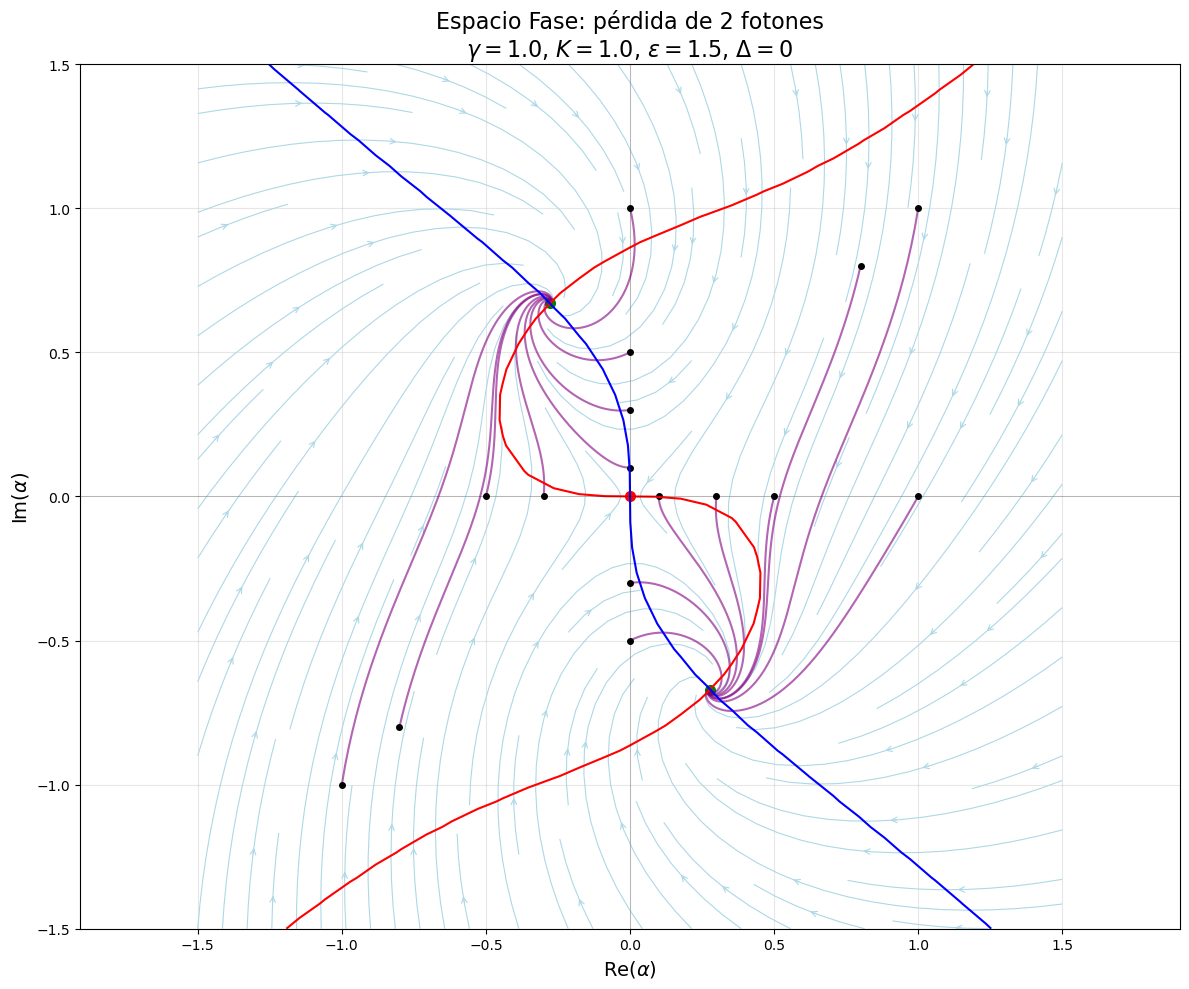

PUNTOS FIJOS - PÉRDIDA DE DOS FOTONES
Trivial:
  α = 0.000000+0.000000j
  |α| = 0.000000
  n = |α|² = 0.000000
  θ = 0.000000 rad

No trivial 1:
  α = 0.278684-0.672804j
  |α| = 0.728238
  n = |α|² = 0.530330
  θ = -1.178097 rad

No trivial 2:
  α = -0.278684+0.672804j
  |α| = 0.728238
  n = |α|² = 0.530330
  θ = 1.963495 rad

RESULTADO ANALITICO DE CAMPO MEDIO
n_MF = epsilon / (2 sqrt(K² + gamma²))
n_MF = 0.530330
|alpha_MF| = 0.728238


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


# ============================================
# PARAMETROS DEL SISTEMA
# ============================================

gamma = 1.0      # Tasa de pérdida de DOS fotones
k = 1.0          # No linealidad Kerr
epsilon = 1.5    # Driving paramétrico

# Delta = 0


# ============================================
# SISTEMA DE ECUACIONES DE CAMPO MEDIO
# ============================================

def sistema(y, t, gamma, k, epsilon):

    x, y_im = y

    alpha = x + 1j*y_im

    n = np.abs(alpha)**2

    # Ecuación de campo medio:
    #
    # d alpha/dt =
    # -(gamma + i k)|alpha|^2 alpha
    # - i epsilon/2 alpha*

    dalpha_dt = (
        -(gamma + 1j*k)*n*alpha
        - 1j*epsilon/2*np.conj(alpha)
    )

    return [
        np.real(dalpha_dt),
        np.imag(dalpha_dt)
    ]


# ============================================
# PUNTOS FIJOS
# ============================================

def puntos_fijos(gamma, k, epsilon):

    puntos = []

    # ----------------------------------------
    # Punto fijo trivial
    # ----------------------------------------

    puntos.append(
        (0.0, 0.0, 'Trivial')
    )

    # ----------------------------------------
    # Puntos fijos no triviales
    #
    # n = epsilon/(2 sqrt(k^2 + gamma^2))
    # ----------------------------------------

    n = epsilon / (2*np.sqrt(k**2 + gamma**2))

    r = np.sqrt(n)

    # Para el estado estacionario:
    #
    # cos(2 theta) = -k/sqrt(k^2 + gamma^2)
    #
    # sin(2 theta) = -gamma/sqrt(k^2 + gamma^2)

    theta = 0.5 * np.arctan2(
        -gamma,
        -k
    )

    # Soluciones relacionadas por Z2:
    # alpha -> -alpha

    alpha1 = r * np.exp(1j*theta)
    alpha2 = -alpha1

    puntos.append(
        (np.real(alpha1),
         np.imag(alpha1),
         'No trivial 1')
    )

    puntos.append(
        (np.real(alpha2),
         np.imag(alpha2),
         'No trivial 2')
    )

    return puntos


# ============================================
# CAMPO VECTORIAL
# ============================================

def campo_vectorial(X, Y, gamma, k, epsilon):

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):

            alpha = X[i,j] + 1j*Y[i,j]

            n = np.abs(alpha)**2

            dalpha_dt = (
                -(gamma + 1j*k)*n*alpha
                - 1j*epsilon/2*np.conj(alpha)
            )

            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# TRAYECTORIA
# ============================================

def trayectoria(alpha0, gamma, k, epsilon,
                t_max=20, n_points=1000):

    t = np.linspace(0, t_max, n_points)

    X_0 = np.real(alpha0)
    Y_0 = np.imag(alpha0)

    sol = odeint(
        sistema,
        [X_0, Y_0],
        t,
        args=(gamma, k, epsilon)
    )

    trayectoria_complex = sol[:,0] + 1j*sol[:,1]

    return trayectoria_complex, t


# ============================================
# NULCLINAS
# ============================================

def nulclinas(X, Y, gamma, k, epsilon):

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):

            alpha = X[i,j] + 1j*Y[i,j]

            n = np.abs(alpha)**2

            dalpha_dt = (
                -(gamma + 1j*k)*n*alpha
                - 1j*epsilon/2*np.conj(alpha)
            )

            U[i,j] = np.real(dalpha_dt)
            V[i,j] = np.imag(dalpha_dt)

    return U, V


# ============================================
# CONFIGURACION DE LA GRAFICA
# ============================================

plt.figure(figsize=(12,10))

lim = 1.5

x = np.linspace(-lim, lim, 35)
y = np.linspace(-lim, lim, 35)

X, Y = np.meshgrid(x, y)


# ============================================
# CAMPO VECTORIAL
# ============================================

U, V = campo_vectorial(
    X, Y,
    gamma,
    k,
    epsilon
)

plt.streamplot(
    X, Y,
    U, V,
    color='lightblue',
    linewidth=0.8,
    density=1.2,
    arrowstyle='->',
    arrowsize=1.0
)


# ============================================
# PUNTOS FIJOS
# ============================================

puntos = puntos_fijos(
    gamma,
    k,
    epsilon
)

for xp, yp, label in puntos:

    if 'Trivial' in label:

        plt.plot(
            xp, yp,
            'ro',
            markersize=7,
            label=label
        )

    else:

        plt.plot(
            xp, yp,
            'go',
            markersize=7,
            label=label
        )


# ============================================
# TRAYECTORIAS
# ============================================

ini_con = [

    0.1 + 0.0j,
    0.0 + 0.1j,

    0.3 + 0.0j,
    0.0 + 0.3j,

    -0.3 + 0.0j,
    0.0 - 0.3j,

    0.5 + 0.0j,
    0.0 + 0.5j,

    -0.5 + 0.0j,
    0.0 - 0.5j,

    0.8 + 0.8j,
    -0.8 - 0.8j,

    1.0 + 0.0j,
    0.0 + 1.0j,

    1.0 + 1.0j,
    -1.0 - 1.0j
]


for alpha0 in ini_con:

    tray, t = trayectoria(
        alpha0,
        gamma,
        k,
        epsilon,
        t_max=30,
        n_points=2000
    )

    plt.plot(
        np.real(tray),
        np.imag(tray),
        color='purple',
        alpha=0.6,
        linewidth=1.5
    )

    # Punto inicial

    plt.plot(
        np.real(alpha0),
        np.imag(alpha0),
        'k.',
        markersize=8
    )


# ============================================
# NULCLINAS
# ============================================

U, V = nulclinas(
    X, Y,
    gamma,
    k,
    epsilon
)

# U = 0
plt.contour(
    X, Y, U,
    levels=[0],
    colors='red',
    linewidths=1.5
)

# V = 0
plt.contour(
    X, Y, V,
    levels=[0],
    colors='blue',
    linewidths=1.5
)


# ============================================
# EJES
# ============================================

plt.axhline(
    0,
    color='black',
    linewidth=0.5,
    alpha=0.3
)

plt.axvline(
    0,
    color='black',
    linewidth=0.5,
    alpha=0.3
)


# ============================================
# ETIQUETAS
# ============================================

plt.xlabel(
    r'Re($\alpha$)',
    fontsize=14
)

plt.ylabel(
    r'Im($\alpha$)',
    fontsize=14
)

plt.title(
    f'Espacio Fase: pérdida de 2 fotones\n'
    f'$\\gamma={gamma}$, $K={k}$, '
    f'$\\epsilon={epsilon}$, $\\Delta=0$',
    fontsize=16
)

plt.grid(
    True,
    alpha=0.3
)

plt.axis('equal')

plt.xlim(-lim, lim)
plt.ylim(-lim, lim)

plt.tight_layout()

plt.savefig('PhaseSpace2ph.pdf')
plt.show()


# ============================================
# INFORMACION DE LOS PUNTOS FIJOS
# ============================================

print("="*60)
print("PUNTOS FIJOS - PÉRDIDA DE DOS FOTONES")
print("="*60)

for xp, yp, label in puntos:

    alpha = xp + 1j*yp

    r = np.abs(alpha)
    n = r**2
    theta = np.angle(alpha)

    print(f"{label}:")
    print(f"  α = {alpha:.6f}")
    print(f"  |α| = {r:.6f}")
    print(f"  n = |α|² = {n:.6f}")
    print(f"  θ = {theta:.6f} rad")
    print()


# ============================================
# RESULTADO ANALITICO
# ============================================

n_mf = epsilon / (
    2*np.sqrt(k**2 + gamma**2)
)

print("="*60)
print("RESULTADO ANALITICO DE CAMPO MEDIO")
print("="*60)

print(
    f"n_MF = epsilon / "
    f"(2 sqrt(K² + gamma²))"
)

print(
    f"n_MF = {n_mf:.6f}"
)

print(
    f"|alpha_MF| = {np.sqrt(n_mf):.6f}"
)